In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [ ]:
# Tạo thư mục dataset trong Colab
!mkdir -p /content/dataset

# Copy toàn bộ dataset từ Drive về Colab
!cp -r "/content/drive/MyDrive/lane.v1i.yolov5pytorch"/* /content/dataset/

In [ ]:
# Huấn luyện mô hình YOLOv5
!python train.py \
  --img 640 \
  --batch 8 \
  --epochs 10 \
  --data /content/dataset/data.yaml \
  --weights yolov5s.pt \
  --name lane_detection_model \
  --workers 8

# Tự động lưu mô hình và toàn bộ kết quả vào Drive
import shutil

src = 'runs/train/lane_detection_model'
dst = '/content/drive/MyDrive/lane_model_backup'

shutil.copytree(src, dst, dirs_exist_ok=True)
print(" Đã sao lưu mô hình và kết quả vào Google Drive.")

In [ ]:
!python train.py \
--img 416 \
--batch 8 \
--epochs 20 \
--data /content/dataset/data.yaml \
--weights /content/drive/MyDrive/lane_model_backup/weights/last.pt \
--name lane_detection_model_resume \
--workers 8


wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-10-26 08:11:54.217753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761466314.238211    8249 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761466314.244440    8249 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761466314.262364    8249 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761466314.262390    8249 computation_placer.cc:177] computation placer already registere

 Các cột có trong file CSV:
['epoch', 'train/box_loss', 'train/obj_loss', 'train/cls_loss', 'metrics/precision', 'metrics/recall', 'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', 'val/box_loss', 'val/obj_loss', 'val/cls_loss', 'x/lr0', 'x/lr1', 'x/lr2']


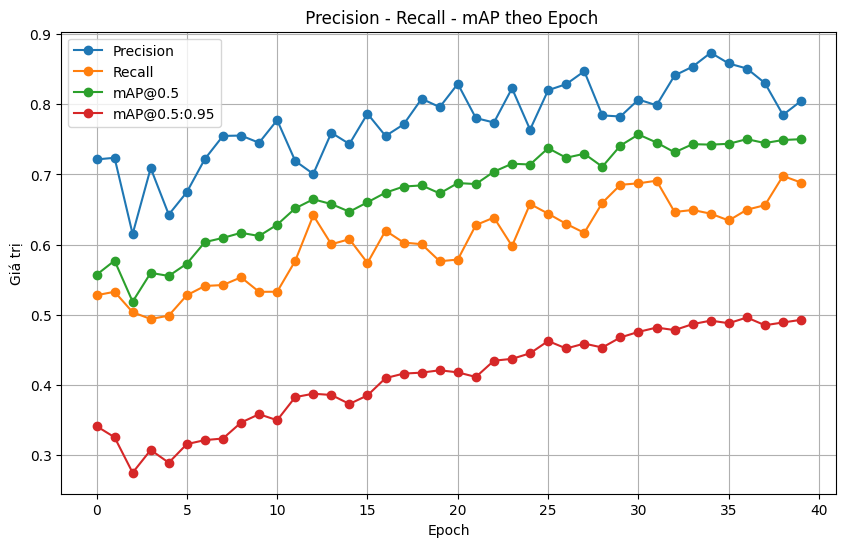

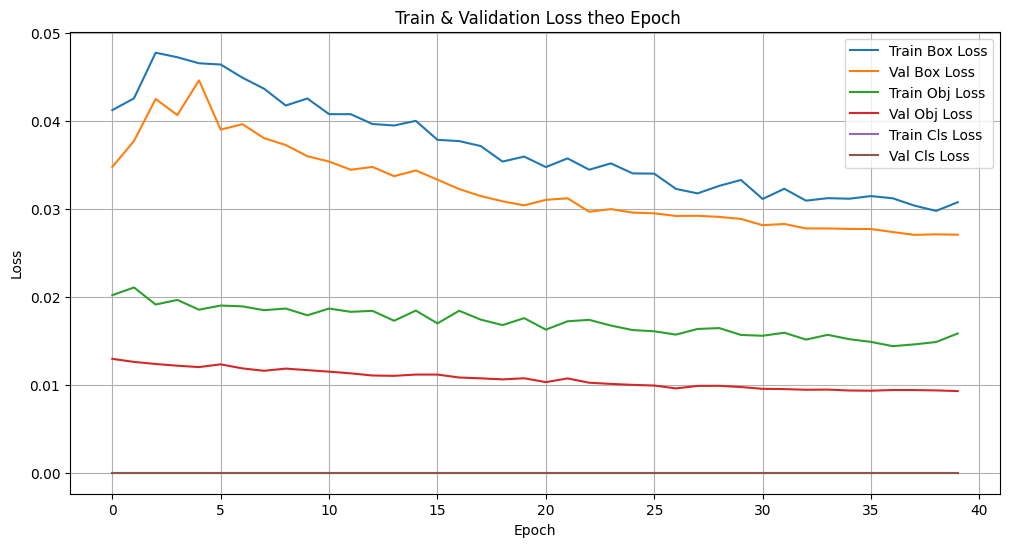

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#  Đường dẫn tới file CSV sau khi train YOLOv5 xong
log_path = "/content/yolov5/runs/train/lane_detection_model_resume2/results.csv"

# Đọc file CSV
df = pd.read_csv(log_path)

# Remove leading spaces from column names
df.columns = df.columns.str.lstrip()

#  In các cột có trong file để kiểm tra nhanh
print(" Các cột có trong file CSV:")
print(df.columns.tolist())


#  1. Vẽ Precision, Recall, mAP

plt.figure(figsize=(10, 6))
plt.plot(df["epoch"], df["metrics/precision"], label="Precision", marker='o')
plt.plot(df["epoch"], df["metrics/recall"], label="Recall", marker='o')
plt.plot(df["epoch"], df["metrics/mAP_0.5"], label="mAP@0.5", marker='o')
plt.plot(df["epoch"], df["metrics/mAP_0.5:0.95"], label="mAP@0.5:0.95", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Giá trị")
plt.title(" Precision - Recall - mAP theo Epoch")
plt.legend()
plt.grid(True)
plt.show()


#  2. Vẽ Train & Validation Loss

plt.figure(figsize=(12, 6))
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.plot(df["epoch"], df["train/obj_loss"], label="Train Obj Loss")
plt.plot(df["epoch"], df["val/obj_loss"], label="Val Obj Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Train & Validation Loss theo Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Đánh giá mô hình và tạo confusion matrix
!python val.py \
--weights runs/train/lane_detection_model_resume2/weights/best.pt \
--data /content/dataset/data.yaml \
--img 416 \
--conf 0.25 \
--iou 0.45 \
--save-jso

val: data=/content/dataset/data.yaml, weights=['runs/train/lane_detection_model_resume2/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.25, iou_thres=0.45, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=True, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.25 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-441-g15c0127a Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/dataset/valid/labels.cache... 102 images, 0 backgrounds, 0 corrupt: 100% 102/102 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 4/4 [00:04<00:00,  1.10s/it]
                   all        102        413      0.873       0.65      0.794      0.567
Speed: 0.6ms pre-process,

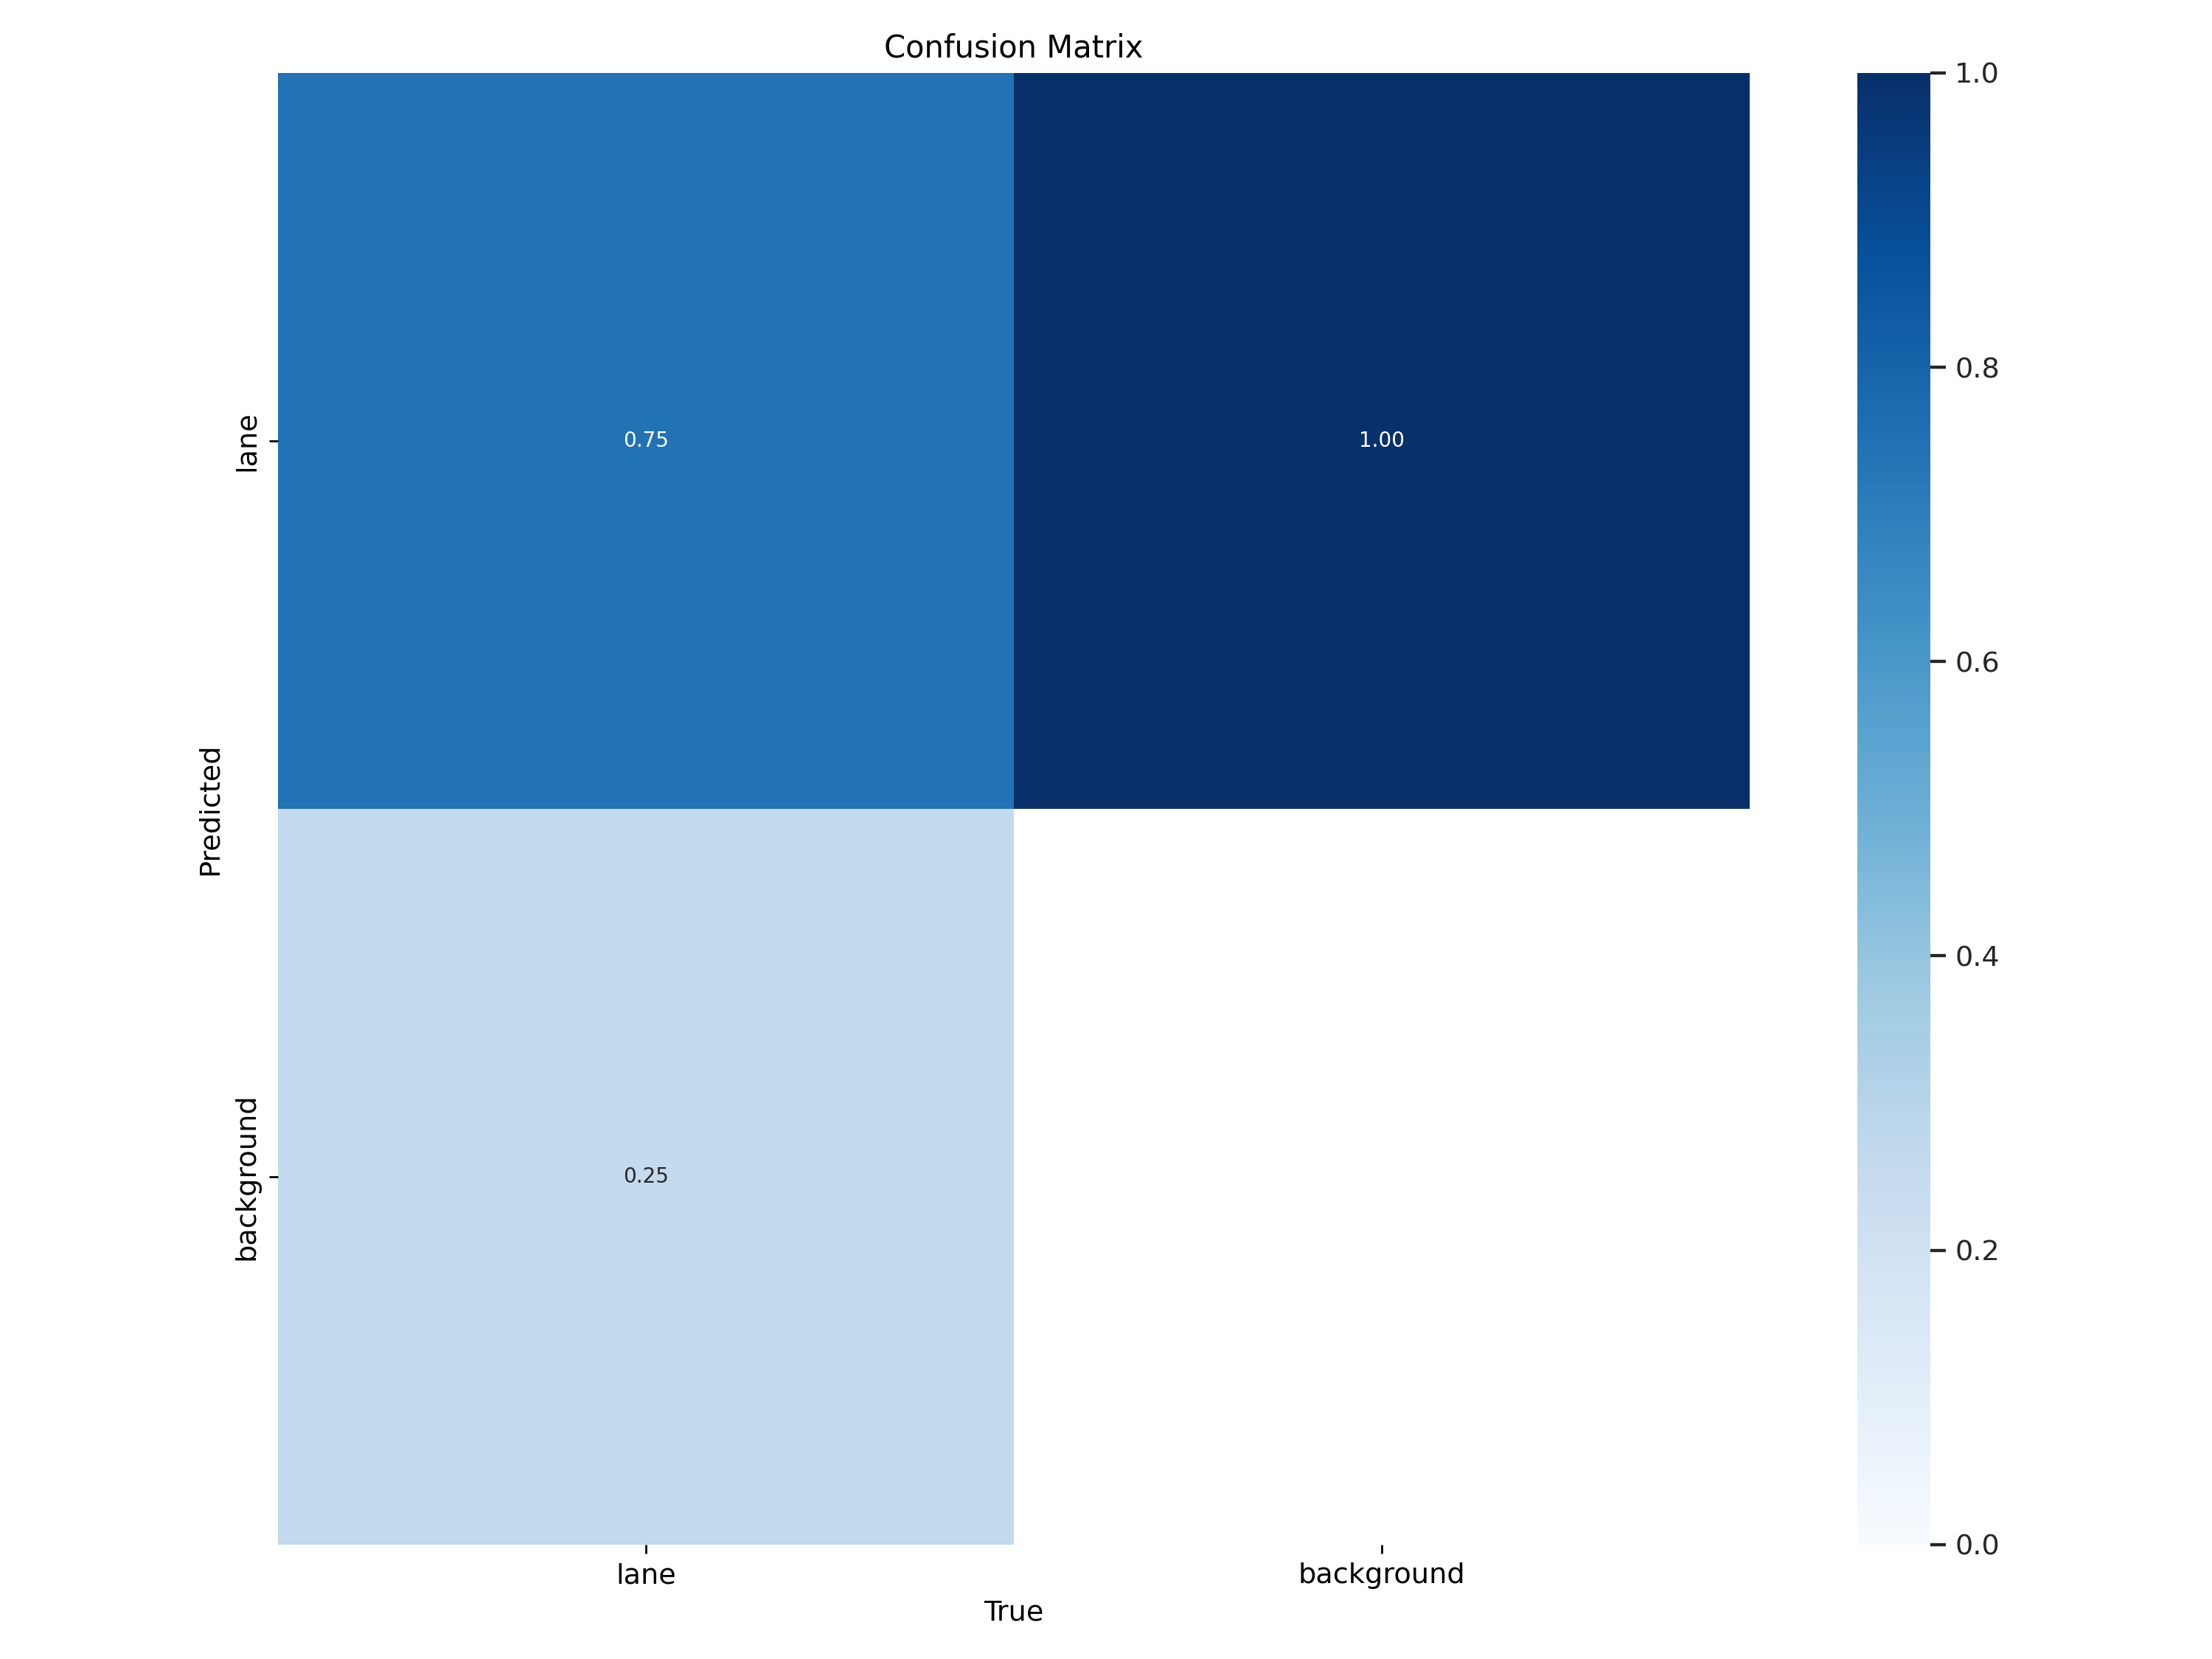

In [ ]:
from IPython.display import Image
Image(filename='runs/val/exp/confusion_matrix.png')

In [ ]:
# Tự động lưu mô hình và toàn bộ kết quả vào Drive
import shutil

src = '/content/yolov5/runs/train/lane_detection_model_resume3'
dst = '/content/drive/MyDrive/lane_model_backup'

shutil.copytree(src, dst, dirs_exist_ok=True)
print("✅ Đã sao lưu mô hình và kết quả vào Google Drive.")


✅ Đã sao lưu mô hình và kết quả vào Google Drive.


In [ ]:
import os

model_path = '/content/yolov5/runs/train/lane_detection_model_resume3/weights/best.pt'
video_path = '/content/Video_Test_New.mp4'

if os.path.exists(model_path) and os.path.exists(video_path):
    print("✅ Mô hình và video đã sẵn sàng. Bắt đầu dự đoán...")
    !python detect.py \
      --weights {model_path} \
      --source {video_path} \
      --conf 0.15 \
      --name lane_video_test
else:
    print("❌ Thiếu mô hình hoặc video. Kiểm tra lại đường dẫn.")

✅ Mô hình và video đã sẵn sàng. Bắt đầu dự đoán...
detect: weights=['/content/yolov5/runs/train/lane_detection_model_resume3/weights/best.pt'], source=/content/Video_Test_New.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.15, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=lane_video_test, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-443-gbe00b6b6 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/1734) /content/Video_Test_New.mp4: 384x640 2 lanes, 33.2ms
video 1/1 (2/1734) /content/Video_Test_New.mp4: 384x640 2 lanes, 7.5ms
video 1/1 (3/1734) /content/Video_Test_New.mp4: 384x640 2 l

In [ ]:
!nvidia-smi

Tue Oct 21 12:35:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----